# Fig. 4i-l spatial significance panels

This notebook organizes the plots from `new_evaluations/spatial/draw_spatial_significance.py`. It keeps the original fixed h5ad and `sq_res` inputs, but redirects outputs to `figures_res/fig4/output/i_l`.


In [1]:
from pathlib import Path
import sys

cwd = Path.cwd()
if (cwd / "figures_res" / "fig4").exists():
    REPO_ROOT = cwd
    FIG4_DIR = cwd / "figures_res" / "fig4"
elif cwd.name == "fig4" and (cwd / "output").exists():
    FIG4_DIR = cwd
    REPO_ROOT = cwd.parents[1]
else:
    raise FileNotFoundError("Run from repo root or figures_res/fig4.")

SPATIAL_DIR = REPO_ROOT / "new_evaluations" / "spatial"
if str(SPATIAL_DIR) not in sys.path:
    sys.path.insert(0, str(SPATIAL_DIR))

import draw_spatial_significance as sig

sig.OUT_DIR = FIG4_DIR / "output" / "i_l"
sig.STATS_DIR = sig.OUT_DIR / "stats"
sig.ensure_dirs()
print(f"Figures will be written to: {sig.OUT_DIR}")
print(f"Stats will be written to: {sig.STATS_DIR}")


Figures will be written to: /home/zzj/lare/figures_res/fig4/output/i_l
Stats will be written to: /home/zzj/lare/figures_res/fig4/output/i_l/stats


## Marker enrichment panels


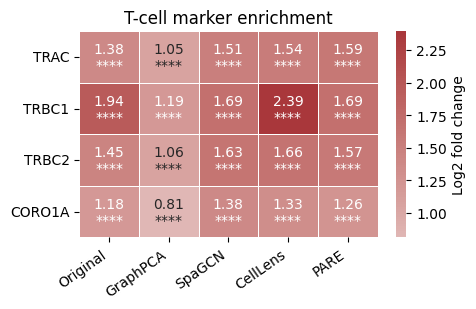

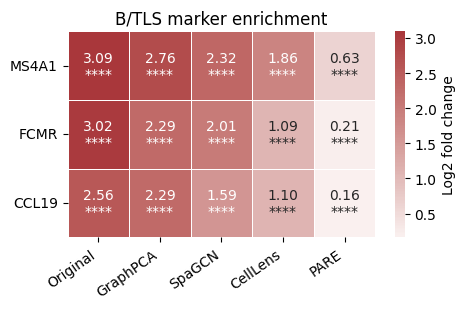

In [2]:
import pandas as pd

# sig.compute_marker_stats() in the source script only builds the T-cell panel.
# Build both T-cell and B/TLS marker tables here before drawing the two heatmaps.
marker_frames = []
for config in sig.METHODS:
    marker_frames.append(sig.marker_stats_for_method(config, "t_cluster", sig.T_MARKERS))
    marker_frames.append(sig.marker_stats_for_method(config, "b_cluster", sig.B_MARKERS))

marker_stats = pd.concat([df for df in marker_frames if not df.empty], ignore_index=True)
marker_stats = sig.bh_adjust(marker_stats)
marker_stats.to_csv(sig.STATS_DIR / "marker_cluster_vs_rest_stats.csv", index=False)

sig.compute_marker_method_comparisons()
sig.plot_marker_heatmap(
    marker_stats,
    panel="t",
    genes=sig.T_MARKERS,
    filename="t_cluster_marker_heatmap.png",
    title="T-cell marker enrichment",
    show=True,
)
sig.plot_marker_heatmap(
    marker_stats,
    panel="b",
    genes=sig.B_MARKERS,
    filename="b_tls_marker_heatmap.png",
    title="B/TLS marker enrichment",
    show=True,
)


## PARE cluster marker dotplot


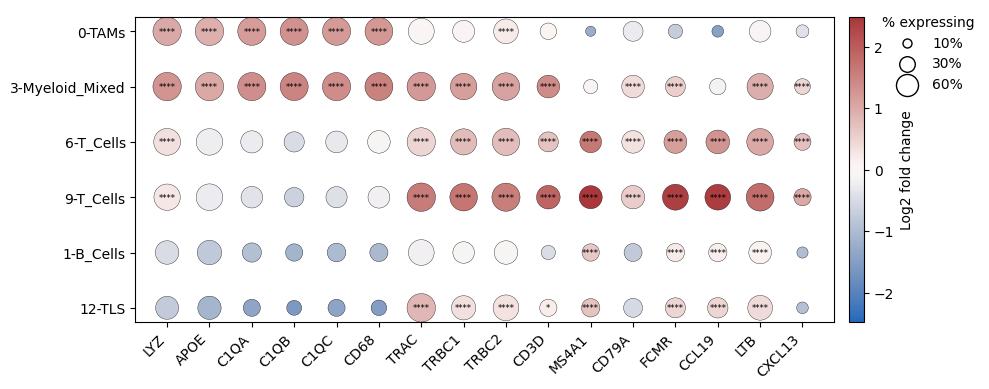

In [3]:
dotplot_stats = sig.compute_wolasso_celltype_dotplot_stats()
sig.plot_wolasso_celltype_dotplot(dotplot_stats, show=True)


## TRAC LISA panels


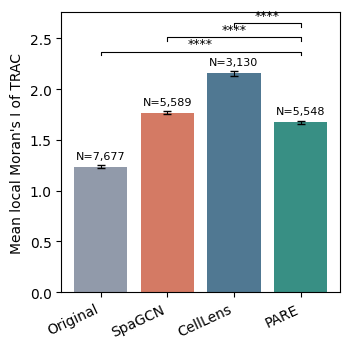

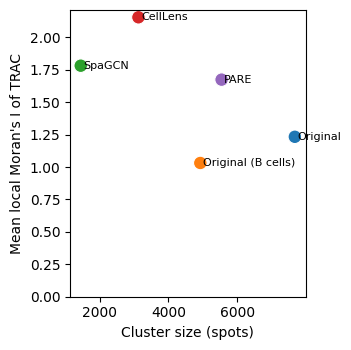

In [ ]:
lisa = sig.load_lisa_summary()
lisa_comp = sig.lisa_bootstrap_comparisons(lisa)
sig.plot_lisa_tradeoff(lisa, show=True)


## TAM island panels


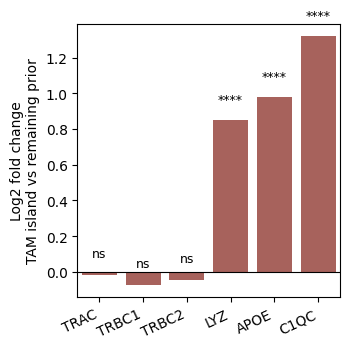

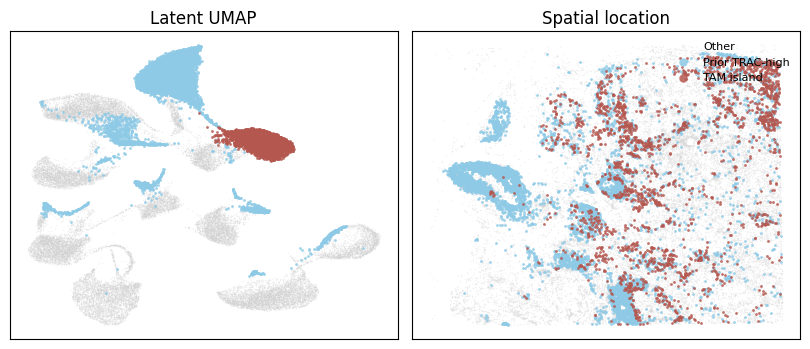

In [ ]:
tam_stats = sig.compute_tam_stats()
sig.plot_tam_marker_bar(tam_stats, show=True)


## Display saved PNG outputs

Run this cell after the plotting cells above to render the saved PNG files directly inside the notebook for review.

In [ ]:
from pathlib import Path
from IPython.display import Image, Markdown, display


def display_saved_pngs(output_dir, width=1000):
    output_dir = Path(output_dir)
    pngs = sorted(output_dir.glob("*.png"))
    if not pngs:
        print(f"No PNG files found in {output_dir}. Run the plotting cells above first.")
        return
    for png in pngs:
        display(Markdown(f"### {png.name}"))
        display(Image(filename=str(png), width=width))


In [ ]:
display_saved_pngs(sig.OUT_DIR, width=900)
